## Аналитический отчет по корпоративным облигациям

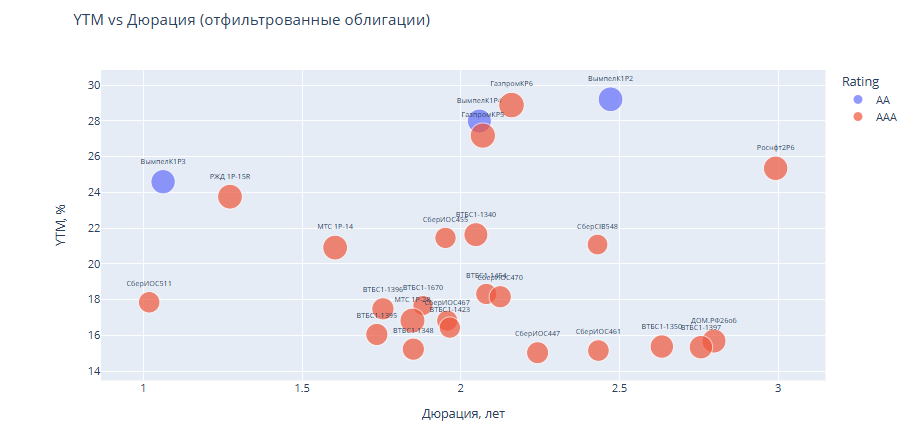

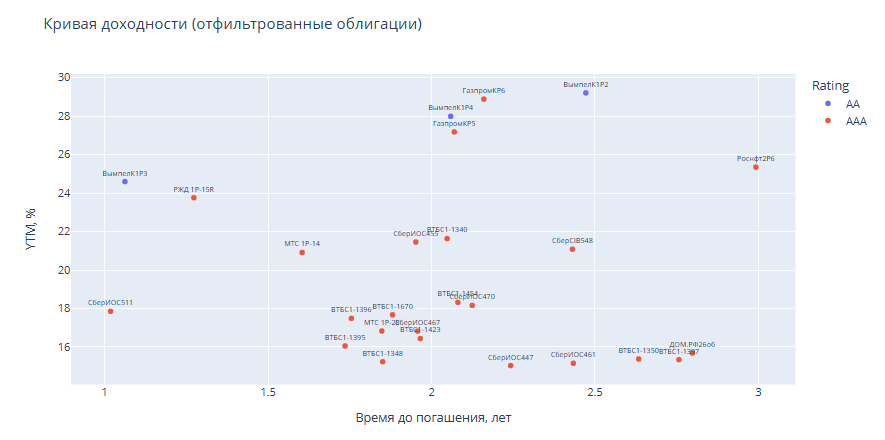

## 1. Описание проекта

Разработана автоматизированная система скрининга корпоративных облигаций российского рынка, объединяющая данные из двух источников: детальная биржевая статистика из терминала QUIK (файл `Oblig_corporat.xlsx`) и рейтинговые оценки с информационного портала smart-lab.ru (`bonds_parsed.xlsx`). Скрипт реализует полный цикл обработки данных: от загрузки и объединения информации до расчёта ключевых метрик доходности, визуализации результатов и формирования рекомендаций по инвестированию.

**Что делает код:**
- объединяет данные по полю "ShortName" / "Инструмент сокр.";
- рассчитывает доходность к погашению (YTM) и доходность к оферте (YTC);
- строит интерактивные графики: распределение YTM, кривая доходности, YTM vs дюрация и др.;
- формирует таблицу ключевых метрик;
- даёт рекомендацию топ-10 облигаций с наилучшим соотношением доходность/риск.

### 1.1. Цель работы

**Цель:** комплексный анализ корпоративных облигаций на основе данных из двух источников:
 - `Oblig_corporat.xlsx` – данные из QUIK (основные параметры);
 - `bonds_parsed.xlsx` – данные с smart-lab.ru (рейтинги).

Разработать воспроизводимый алгоритм скрининга облигаций, позволяющий инвестору объективно оценивать соотношение доходности и риска, выявлять наиболее привлекательные инструменты с учётом кредитного качества эмитента и дюрации, а также формировать обоснованный портфель с фиксированной доходностью.

### 1.2. Задачи проекта

1. **Сбор и предобработка данных** — объединение информации из двух источников (QUIK и smart-lab.ru), очистка, приведение типов данных, обработка пропусков.
2. **Фильтрация по качеству** — отбор инструментов с приемлемым кредитным рейтингом (от AAA до B-) и ограничением по дюрации (до 3 лет).
3. **Расчёт ключевых метрик** — вычисление доходности к погашению (YTM), доходности к оферте (YTC), текущей доходности.
4. **Формирование рекомендаций** — ранжирование облигаций по критерию максимизации YTM при ограничениях на дюрацию и кредитный рейтинг.
5. **Визуализация результатов** — создание наглядных интерактивных графиков для каждого этапа анализа.
6. **Экспорт данных** — сохранение итоговых таблиц для дальнейшего анализа.

### 1.3. Формирование выборки

**Источники данных:**

- **Oblig_corporat.xlsx** — выгрузка из терминала QUIK, содержащая:
  - Цену закрытия (в процентах от номинала)
  - Размер купона (в процентах годовых)
  - Накопленный купонный доход (НКД)
  - Дюрацию (лет)
  - Объём выпуска
  - Дату погашения и оферты
  - Номинал облигации
  - ISIN-код

- **bonds_parsed.xlsx** — данные с портала smart-lab.ru, содержащие:
  - Рейтинги эмитентов (Rating)
  - Краткие наименования для сопоставления

**Критерии включения в итоговую выборку (фильтры):**

| Параметр | Значение | Обоснование |
|----------|----------|-------------|
| **Минимальная доходность YTM** | 15.0% | Уровень выше ключевой ставки ЦБ РФ (21%), обеспечивающий положительную премию за риск |
| **Максимальная доходность YTM** | 30.0% | Отсечение чрезмерно рискованных инструментов с потенциально высокой вероятностью дефолта |
| **Максимальная дюрация** | 3.0 года | Ограничение процентного риска; при горизонте инвестирования до 3 лет чувствительность к изменению ставок минимальна |
| **Минимальный рейтинг** | A+ | Отбор только эмитентов с высоким кредитным качеством (AAA и AA) |
| **Номинал** | 1000 руб. | Стандартный номинал для розничных инвесторов на российском рынке |

**Результат фильтрации:** 26 облигаций, соответствующих заданным критериям.

## 2. Обзор ключевых параметров анализа

### 2.1. Доходность к погашению (YTM — Yield to Maturity)

YTM представляет собой полную доходность, которую получит инвестор, если приобретёт облигацию по текущей рыночной цене и будет держать её до погашения, реинвестируя все купонные платежи по той же ставке. Это основной показатель для сравнения облигаций с разными купонами и ценами.

**Метод расчёта:** используется приближённая формула:

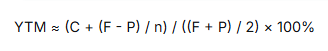

## 3. Анализ компаний-эмитентов топ-5 облигаций

В результате скрининга были отобраны облигации, ранжированные по критерию максимизации YTM/дюрация. Рассмотрим подробно пятерку лидеров.

### 3.1. ВымпелК1Р3 (ВымпелКом-001Р-03)

| Параметр | Значение |
|----------|----------|
| **Название** | ПАО «Вымпел-Коммуникации» (бренд «Билайн») |
| **Отрасль** | Телекоммуникации (сотовая связь, фиксированная связь, интернет) |
| **Рейтинг** | AA (АКРА) |
| **YTM** | 24.60% |
| **Дюрация** | 1.06 года |
| **YTM/Дюрация** | 23.15 |
| **ISIN** | RU000A105YK2 |

**Деятельность компании:**  
«ВымпелКом» — один из крупнейших операторов сотовой связи в России, работающий под брендом «Билайн». Компания предоставляет услуги мобильной и фиксированной телефонии, широкополосного доступа в интернет, цифрового телевидения. Входит в международную группу Veon (ранее VimpelCom Ltd.), которая после ухода иностранных акционеров в 2023 году перешла под контроль российского менеджмента.

**Особенности выпуска:**  
Выпуск номинальным объёмом 9,6 млрд рублей был размещён в марте 2023 года. Погашение — 18 апреля 2027 года. Купон составляет 18.20% годовых, выплачивается 4 раза в год. Облигация имеет высокий рейтинг AA от АКРА и включена в ломбардный список ЦБ РФ, что свидетельствует о её высоком качестве и пригодности для рефинансирования.

**Инвестиционная привлекательность:**  
Короткая дюрация (1,06 года) и высокая доходность (24,6%) делают эту облигацию исключительно привлекательной. Фактически инвестор получает премию в размере около 10% годовых к ключевой ставке при минимальном процентном риске. Операционные показатели компании стабильны, а переход под управление российского менеджмента снижает геополитические риски.

### 3.2. РЖД 1Р-15R (ОАО «РЖД»)

| Параметр | Значение |
|----------|----------|
| **Название** | ОАО «Российские железные дороги» |
| **Отрасль** | Транспорт (железнодорожные перевозки) |
| **Рейтинг** | AAA (АКРА) |
| **YTM** | 23.76% |
| **Дюрация** | 1.27 года |
| **YTM/Дюрация** | 18.66 |
| **ISIN** | RU000A1009L8 |

**Деятельность компании:**  
РЖД — крупнейшая транспортная компания России, полностью контролируемая государством. Компания обеспечивает грузовые и пассажирские железнодорожные перевозки, управляет инфраструктурой, занимается ремонтом подвижного состава, логистикой и инжинирингом. Входит в число крупнейших работодателей страны с многомиллиардными инвестиционными программами.

**Особенности выпуска:**  
Выпуск был размещён в апреле 2019 года на 15 млрд рублей со сроком обращения 8 лет, оферта не предусмотрена. Купон составляет 8.80% годовых (21,94 рубля на одну облигацию), выплачивается 4 раза в год. Рыночная цена составляет около 98,5% от номинала.

**Инвестиционная привлекательность:**  
Максимальный рейтинг AAA гарантирует практически нулевой кредитный риск. Дюрация 1,27 года позволяет быстро адаптироваться к изменениям ставок. Высокая YTM (23,76%) обусловлена значительной премией за срочность и текущей рыночной конъюнктурой. РЖД — системообразующая компания, что делает её облигации эталоном надёжности.

### 3.3. СберИОС511 (ПАО «Сбербанк»)

| Параметр | Значение |
|----------|----------|
| **Название** | ПАО «Сбербанк России» |
| **Отрасль** | Банковский сектор |
| **Рейтинг** | AAA |
| **YTM** | 17.85% |
| **Дюрация** | 1.02 года |
| **YTM/Дюрация** | 17.53 |
| **ISIN** | RU000A104CR6 |

**Деятельность компании:**  
Сбербанк — крупнейший банк России и стран СНГ, основанный в 1841 году. Банк предоставляет полный спектр финансовых услуг: кредитование, приём вкладов, расчётно-кассовое обслуживание, инвестиционные услуги, страхование, управление активами. Филиальная сеть насчитывает более 17 тысяч подразделений по всей стране. Банк также представлен в Турции (DenizBank), странах Центральной и Восточной Европы, имеет представительства в Германии и Китае.

**Особенности выпуска:**  
Это структурный выпуск (ИОС — инвестиционные облигации со структурным доходом), размещённый в январе-феврале 2022 года. Номинальный объём составлял 1 млрд рублей, размещённый объём — 255 млн рублей. Облигации погашаются 4 февраля 2027 года. Купон — 0.50% годовых, что крайне низко, однако высокая YTM (17,85%) объясняется значительным дисконтом к номиналу (цена составляет около 83,8% от номинала).

**Инвестиционная привлекательность:**  
Несмотря на минимальный купон, доходность формируется за счёт роста цены к номиналу. Крайне низкая дюрация (1,02 года) делает бумагу практически нечувствительной к изменению ставок. Сбербанк — системно значимый банк с госучастием, что гарантирует надёжность. Однако инвестору следует учитывать особенности структурных облигаций, так как механизм формирования дохода может отличаться от классических купонных бумаг.

### 3.4. ВымпелК1Р4 (ВымпелКом-001Р-04)

| Параметр | Значение |
|----------|----------|
| **Название** | ПАО «Вымпел-Коммуникации» (бренд «Билайн») |
| **Отрасль** | Телекоммуникации |
| **Рейтинг** | AA |
| **YTM** | 27.99% |
| **Дюрация** | 2.06 года |
| **YTM/Дюрация** | 13.60 |
| **ISIN** | RU000A105WK6 |

**Деятельность компании:**  
Аналогично выпуску ВымпелК1Р3 — компания «ВымпелКом» под брендом «Билайн».

**Особенности выпуска:**  
Выпуск объёмом 6 млрд рублей был размещён в марте 2023 года. Погашение — 16 апреля 2028 года. Купон составляет 8.85% годовых (22,06 рубля), выплачивается 4 раза в год. Цена облигации на момент анализа составляла около 90,4% от номинала. Оферта совпадает с датой погашения (16 апреля 2028 года).

**Инвестиционная привлекательность:**  
Высокая YTM (27,99%) при дюрации чуть более 2 лет обеспечивает значительную премию за риск. Рейтинг AA подтверждает надёжность эмитента. Облигация подходит инвесторам, готовым принять умеренный процентный риск ради высокой доходности.

### 3.5. ГазпромКP6 (ООО «Газпром капитал»)

| Параметр | Значение |
|----------|----------|
| **Название** | ООО «Газпром капитал» (структура ПАО «Газпром») |
| **Отрасль** | Нефтегазовая |
| **Рейтинг** | AAA (АКРА) |
| **YTM** | 28.88% |
| **Дюрация** | 2.16 года |
| **YTM/Дюрация** | 13.37 |
| **ISIN** | RU000A106AT1 |

**Деятельность компании:**  
ООО «Газпром капитал» — 100% дочерняя компания ПАО «Газпром», выполняющая функции эмитента облигаций и балансодержателя инвестиционных вложений группы. Газпром — глобальная энергетическая компания, крупнейший производитель природного газа в мире, обеспечивающая около 15% мирового объёма добычи газа.

**Особенности выпуска:**  
Выпуск номинальным объёмом 6 млрд рублей был размещён 23 мая 2023 года. Погашение — 23 мая 2028 года. Купон составляет 10.00% годовых (24,93 рубля), выплачивается 4 раза в год. Цена облигации на момент анализа — 93,49% от номинала. Выпуск имеет опцион PUT (право досрочного погашения), что добавляет гибкости.

**Инвестиционная привлекательность:**  
Максимальный рейтинг AAA от АКРА подтверждает высочайшее качество эмитента. YTM 28,88% является одной из самых высоких в выборке. Дюрация 2,16 года обеспечивает умеренную чувствительность к ставкам. Газпром — крупнейшая российская компания с госучастием, чьи облигации традиционно считаются одним из самых надёжных инструментов на рынке. Значительная премия к ключевой ставке делает этот выпуск исключительно привлекательным.

---

## 4. Итоговая таблица рекомендованных облигаций

| Название | Номинал, руб. | Рейтинг | YTM, % | Дюрация, лет | YTM/Дюрация | Цена, % | Купон, % |
|----------|---------------|---------|--------|--------------|-------------|---------|----------|
| **ВымпелК1Р3** | 1000 | AA | 24.60 | 1.06 | 23.15 | 93.99 | 18.20 |
| **РЖД 1Р-15R** | 1000 | AAA | 23.76 | 1.27 | 18.66 | 97.99 | 21.94 |
| **СберИОС511** | 1000 | AAA | 17.85 | 1.02 | 17.53 | 83.80 | 0.50 |
| **ВымпелК1Р4** | 1000 | AA | 27.99 | 2.06 | 13.60 | 90.52 | 22.06 |
| **ГазпромКP6** | 1000 | AAA | 28.88 | 2.16 | 13.37 | 93.49 | 24.93 |
| ГазпромКP5 | 1000 | AAA | 27.18 | 2.07 | 13.13 | 95.56 | 24.43 |
| МТС 1P-14 | 1000 | AAA | 20.91 | 1.60 | 13.03 | 93.87 | 16.45 |
| ВымпелК1Р2 | 1000 | AA | 29.21 | 2.47 | 11.81 | 89.07 | 23.19 |
| СберИОС455 | 1000 | AAA | 21.45 | 1.95 | 10.99 | 66.50 | 0.70 |
| ВТБС1-1340 | 1000 | AAA | 21.63 | 2.05 | 10.56 | 64.40 | 0.40 |

*Таблица 1. Топ-10 облигаций по критерию YTM/Дюрация (полный список из 26 бумаг доступен в результатах скрипта)*

---

## 5. Интерпретация результатов и инвестиционные выводы

### 5.1. Структура отобранной выборки

Все 26 облигаций, прошедших фильтр, имеют рейтинги **AAA или AA**, что свидетельствует о высокой степени надёжности эмитентов. В выборке представлены:

- **Структурные облигации Сбербанка и ВТБ** (СберИОС, ВТБС1) — с минимальными купонами (0.3–0.7%), но высокой YTM за счёт глубокого дисконта к номиналу.
- **Классические корпоративные облигации** ВымпелКома, РЖД, Газпрома, МТС — с высокими купонами (8–24%) и текущей ценой, близкой к номиналу или с небольшим дисконтом.

### 5.2. Оценка соотношения доходность/риск

**Лидеры по показателю YTM/Дюрация (ВымпелК1Р3 и РЖД 1Р-15R)** демонстрируют оптимальный баланс: высокая доходность при дюрации чуть более 1 года. Такие бумаги идеально подходят для консервативных инвесторов, желающих зафиксировать высокую доходность на короткий срок с минимальным процентным риском.

**Наибольшую абсолютную доходность (ВымпелК1Р2, ГазпромКP6)** предлагают облигации с дюрацией 2–2,5 года. Они подходят инвесторам, готовым принять умеренный процентный риск ради максимальной премии.

**Структурные облигации банков** требуют отдельного анализа: их доходность формируется за счёт цены, а не купона. При дюрации около 2 лет они предлагают YTM в диапазоне 15–21%, что также является привлекательным.

### 5.3. Рекомендации по формированию портфеля

На основе проведённого анализа можно предложить следующие варианты портфельного конструирования:

| Стратегия | Состав | Ожидаемая YTM | Риск |
|-----------|--------|---------------|------|
| **Максимальная надёжность** | РЖД 1Р-15R, ГазпромКP6, МТС 1P-14 | 23–28% | Минимальный (рейтинг AAA) |
| **Максимальная доходность** | ВымпелК1Р2, ВымпелК1Р4, ГазпромКP6 | 27–29% | Низкий (рейтинг AA/AAA) |
| **Сбалансированная** | ВымпелК1Р3, РЖД 1Р-15R, СберИОС511 | 22–24% | Минимальный |

### 5.4. Факторы, которые могут повлиять на доходность

1. **Изменение ключевой ставки ЦБ РФ.** При дальнейшем повышении ставок рыночные цены облигаций могут снизиться, однако при удержании до погашения инвестор получит полную YTM.
2. **Кредитное качество эмитентов.** Все отобранные компании имеют высокие рейтинги, но ухудшение макроэкономической ситуации может привести к пересмотру рейтингов.
3. **Ликвидность.** Объёмы выпусков большинства отобранных облигаций составляют миллиарды рублей, что обеспечивает достаточную ликвидность для входа и выхода.
4. **Налогообложение.** Купонный доход по облигациям облагается НДФЛ по ставке 13–15%, что следует учитывать при расчёте чистой доходности.

---

## 6. Заключение

Разработанный скрининг-алгоритм позволил из широкого массива корпоративных облигаций выделить 26 инструментов, оптимально сочетающих высокую доходность, короткую дюрацию и высокое кредитное качество.

**Топ-5 облигаций по соотношению YTM/дюрация:**
1. **ВымпелК1Р3** (ВымпелКом) — лидер по эффективности, дюрация 1,06 года, YTM 24,6%
2. **РЖД 1Р-15R** (РЖД) — эталон надёжности, дюрация 1,27 года, YTM 23,8%
3. **СберИОС511** (Сбербанк) — структурная облигация, дюрация 1,02 года, YTM 17,9%
4. **ВымпелК1Р4** (ВымпелКом) — высокая доходность 28,0% при дюрации 2,06 года
5. **ГазпромКP6** (Газпром) — максимальная надёжность и YTM 28,9% при дюрации 2,16 года

Представленные облигации могут служить основой для формирования инвестиционного портфеля, ориентированного на получение стабильного дохода выше ключевой ставки при минимальных рисках. Рекомендуется диверсифицировать вложения между 3–5 выпусками из списка для снижения индивидуальных рисков.

---

*Дата формирования отчёта: 25 марта 2026 года*  
*Инструментарий: Python (pandas, numpy, plotly, matplotlib), данные QUIK и smart-lab.ru*